In [21]:
import os
import zipfile
from pathlib import Path
from typing import Callable, Tuple

import gdown

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import VGG16_Weights

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from tqdm.notebook import tqdm
from IPython.display import Image
from PIL import Image

# Variable declaration

In [22]:
url__data_origin = "https://drive.google.com/drive/folders/10KMK0rNB43V2g30NcA1RYipL535DuZ-h"
fil__raw_dataset_trainvalidation = "train_val.zip"
fil__raw_dataset_test = "TEST.zip"

dir__running = os.path.join(os.getcwd(), "..")
dir__raw_data = os.path.join(dir__running, "data", "raw")

path__raw_dataset_trainvalidation = os.path.join(dir__raw_data, fil__raw_dataset_trainvalidation)
path__raw_dataset_test = os.path.join(dir__raw_data, fil__raw_dataset_test)

dir__dataset = os.path.join(dir__running, "data", "dataset")
dir__dataset_trainvalidation = os.path.join(dir__dataset, "train-validation")
dir__dataset_test = os.path.join(dir__dataset, "test")

dir__dataset_trainvalidation_images = os.path.join(dir__dataset_trainvalidation, "images")
dir__dataset_trainvalidation_masks = os.path.join(dir__dataset_trainvalidation, "masks")

dir__dataset_test_images = os.path.join(dir__dataset_test, "images")
dir__dataset_test_masks = os.path.join(dir__dataset_test, "masks")

# Data acquisition

In [23]:
def ensure_dir(dir):
    if not os.path.exists(dir):
        os.makedirs(dir)


def download_from_google_drive(url, file_path):
    print(f"Downloading {url} to {file_path}...")
    gdown.download_folder(url__data_origin, quiet=False, output=file_path)
    print("Download completed.")


def unzip_file(zip_path, target_dir):
    ensure_dir(target_dir)
    if not os.path.exists(target_dir) or len(os.listdir(target_dir)) == 0:
        print(f"extracting {zip_path} to {target_dir}...")
        file_name = os.path.basename(zip_path)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(target_dir)
        for file in os.listdir(os.path.join(target_dir, file_name.split(".")[0])):
            os.rename(
                os.path.join(target_dir, file_name.split(".")[0], file),
                os.path.join(target_dir, file),
            )
        os.rmdir(os.path.join(target_dir, file_name.split(".")[0]))
        print(f"{zip_path} successfully extracted to {target_dir}.")
    else:
        print(f"{zip_path} already extracted to {target_dir}.")

In [24]:
ensure_dir(dir__raw_data)

if not os.path.isfile(path__raw_dataset_trainvalidation) or not os.path.isfile(path__raw_dataset_test):
    download_from_google_drive(url__data_origin, dir__raw_data)
else:
    print("Raw datasets already downloaded.")

if not os.path.isfile(path__raw_dataset_trainvalidation) or not os.path.isfile(path__raw_dataset_test):
    raise FileNotFoundError("Raw datasets not found.")

unzip_file(path__raw_dataset_trainvalidation, dir__dataset_trainvalidation)
unzip_file(path__raw_dataset_test, dir__dataset_test)

Raw datasets already downloaded.
/content/../data/raw/train_val.zip already extracted to /content/../data/dataset/train-validation.
/content/../data/raw/TEST.zip already extracted to /content/../data/dataset/test.


In [25]:
trainvalidation_tuples_paths = [
    (
        os.path.join(dir__dataset_trainvalidation_images, file_name),
        os.path.join(dir__dataset_trainvalidation_masks, file_name.split(".")[0] + ".bmp"),
    )
    for file_name in os.listdir(dir__dataset_trainvalidation_images)
]
test_tuples_paths = [
    (
        os.path.join(dir__dataset_test_images, file_name),
        os.path.join(dir__dataset_test_masks, file_name.split(".")[0] + ".bmp"),
    )
    for file_name in os.listdir(dir__dataset_test_images)
]

# Data analysis

## Categories

| Color                                 | Description               |
| ------------------------------------- | ------------------------- |
| <span style="color:#000000;">⬤</span> | Background waterbody      |
| <span style="color:#0000FF;">⬤</span> | Human divers              |
| <span style="color:#00FF00;">⬤</span> | Plants/sea-grass          |
| <span style="color:#00FFFF;">⬤</span> | Wrecks/ruins              |
| <span style="color:#FF0000;">⬤</span> | Robots/instruments        |
| <span style="color:#FF00FF;">⬤</span> | Reefs and invertebrates   |
| <span style="color:#FFFF00;">⬤</span> | Fish and vertebrates      |
| <span style="color:#FFFFFF;">⬤</span> | Sand/sea-floor (& rocks)  |


Train-validation dataset contains 1525 images and masks.
Test dataset contains 110 images and masks.

Image dimensions:
  - (480, 640, 3): 1329
  - (720, 1280, 3): 57
  - (448, 480, 3): 16
  - (720, 1152, 3): 8
  - (1080, 1906, 3): 17
  - (360, 640, 3): 17
  - (480, 584, 3): 5
  - (540, 960, 3): 130
  - (600, 800, 3): 13
  - (960, 1280, 3): 1
  - (416, 416, 3): 5
  - (375, 590, 3): 31
  - (435, 910, 3): 6


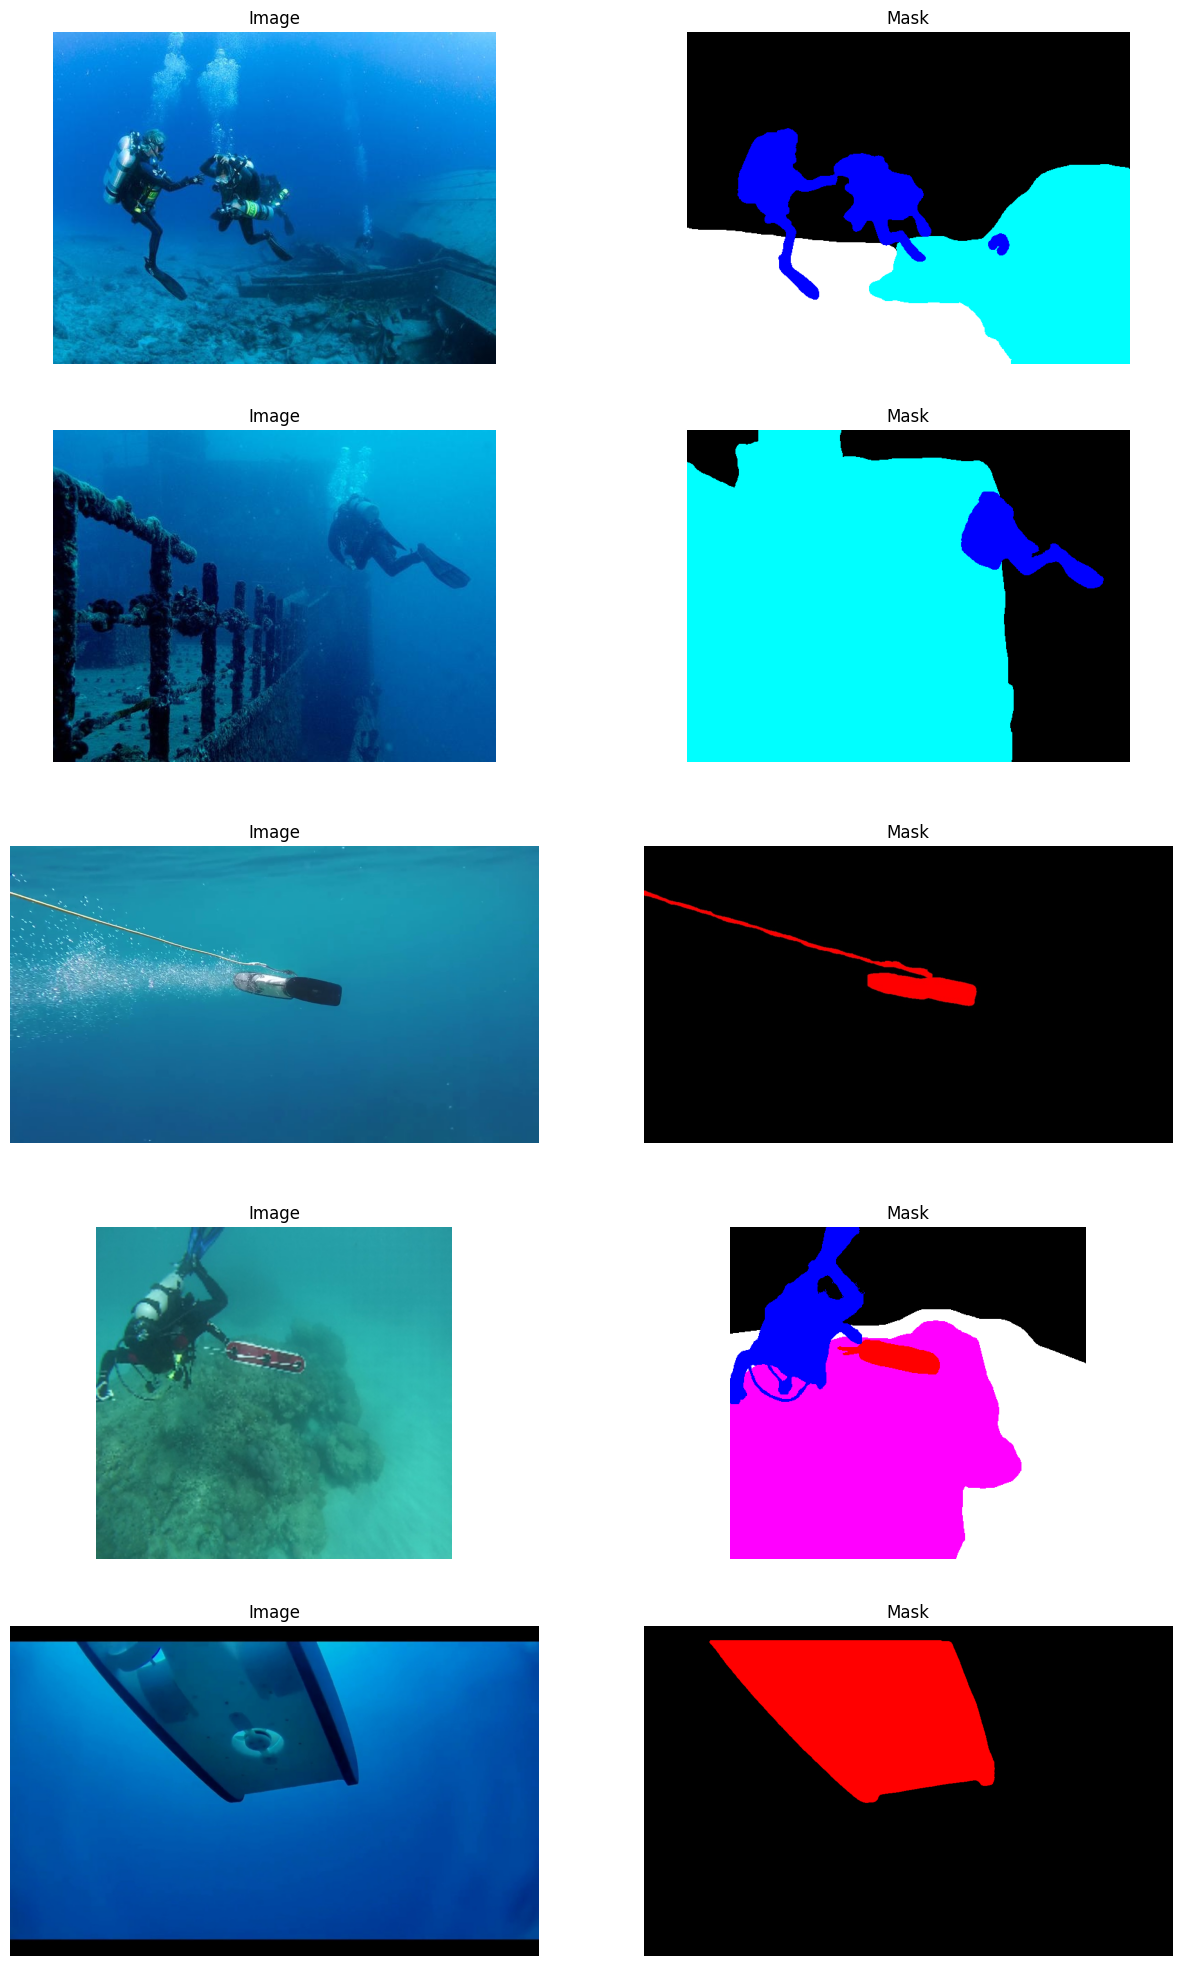

In [ ]:
print(f"Train-validation dataset contains {len(trainvalidation_tuples_paths)} images and masks.")
print(f"Test dataset contains {len(test_tuples_paths)} images and masks.")

image_dims = {}
for image_path, mask_path in trainvalidation_tuples_paths + test_tuples_paths:
    image = plt.imread(image_path)

    count = image_dims[image.shape] if image.shape in image_dims else 0
    image_dims[image.shape] = count + 1

print("\nImage dimensions:")
for dim, count in image_dims.items():
    print(f"  - {dim}: {count}")

fig, ax = plt.subplots(5, 2, figsize=(15, 25))

for i in range(5):
    _ = ax[i][0].axis("off")
    _ = ax[i][1].axis("off")

    _ = ax[i][0].imshow(plt.imread(trainvalidation_tuples_paths[i][0]))
    _ = ax[i][0].set_title("Image")

    _ = ax[i][1].imshow(plt.imread(trainvalidation_tuples_paths[i][1]))
    _ = ax[i][1].set_title("Mask")

plt.show()

# Model

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


## Dataset

In [41]:
class SuimDataset(Dataset):
    def __init__(
        self,
        data_tuples_paths,
        transform_images: Callable = None,
        transform_labels: Callable = None,
    ):
        """
        Initializes the dataset.

        Args:
            data_tuples_paths (Path): Path to the dataset directory.
            transform_images (callable, optional): Transformation function for images.
            transform_labels (callable, optional): Transformation function for labels.
        """
        self.data_tuples_paths = data_tuples_paths

        self.transform_images = transform_images
        self.transform_labels = transform_labels

        self.classes = [
            (0, 0, 0),        # #000000 --> Background waterbody
            (0, 0, 255),      # #0000FF --> Human divers
            (0, 255, 0),      # #00FF00 --> Plants/sea-grass
            (0, 255, 255),    # #00FFFF --> Wrecks/ruins
            (255, 0, 0),      # #FF0000 --> Robots/instruments
            (255, 0, 255),    # #FF00FF --> Reefs and invertebrates
            (255, 255, 0),    # #FFFF00 --> Fish and vertebrates
            (255, 255, 255),  # #FFFFFF --> Sand/sea-floor (& rocks)
        ]

    def __len__(self) -> int:
        """
        Returns the length of the dataset.
        """
        return len(self.data_tuples_paths)

    def __getitem__(self, idx):
        """
        Retrieves the image and corresponding label masks for a given index.

        Args:
            idx (int): The index of the item to retrieve.

        Returns:
            tuple: A tuple containing:
                - image (torch.Tensor | Image.Image): The transformed image or original image.
                - label_masks (torch.Tensor): A binary mask tensor of shape (K, H, W) where K is the number of classes.
                  Each channel represents the binary mask for a specific class.
                - labels_tensor (torch.Tensor): A segmentation map tensor of shape (1, H, W) indicating class indices
                  for each pixel.
        """
        image_path, label_path = self.data_tuples_paths[idx]

        image = Image.open(image_path).convert("RGB")
        label = Image.open(label_path).convert("RGB")

        label_array = np.array(label)
        label_tensor = torch.zeros(label_array.shape[:2], dtype=torch.long)

        for class_idx, color in enumerate(self.classes):
            mask = np.all(label_array == np.array(color), axis=-1)
            label_tensor[mask] = class_idx

        if self.transform_images:
            image = self.transform_images(image)
        else:
            image = torch.tensor(np.array(image), dtype=torch.float32).permute(2, 0, 1) / 255.0

        if self.transform_labels:
            label_pil = Image.fromarray(label_tensor.numpy().astype(np.uint8))  # Convert to PIL.Image
            label_pil = self.transform_labels(label_pil)  # Apply transformations
            label_tensor = torch.tensor(np.array(label_pil), dtype=torch.long)  # Convert back to tensor

        label_masks = F.one_hot(label_tensor, num_classes=len(self.classes)) \
            .permute(2, 0, 1) \
            .float()

        return image, label_masks, label_tensor

In [42]:
# PIL Image -> Tensor
transform_images = transforms.Compose(
    [
        transforms.Resize((320, 256)),
        # transforms.CenterCrop((256, 256)), ## resize instead of crop
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
transform_labels = transforms.Compose(
    [
        #transforms.ToPILImage()
        transforms.Resize((320, 256)),
        # transforms.CenterCrop((256, 256)), ## resize instead of crop
        #transforms.ToTensor(),
    ]
)


trainvalidation_dataset = SuimDataset(trainvalidation_tuples_paths, transform_images, transform_labels)
test_dataset = SuimDataset(test_tuples_paths, transform_images, transform_labels)

batch_size = 8
num_workers = 8
trainvalidation_dataset_loader = DataLoader(trainvalidation_dataset, batch_size=batch_size, shuffle=True) #, num_workers=num_workers, pin_memory=True)
test_dataset_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) #, num_workers=num_workers, pin_memory=True)

## Own implementation

In [17]:
class EncoderBlock(nn.Module):

    def __init__(
            self,
            in_channels: int,
            out_channels: int,
            kernel_size=3,
            padding=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            stride=1,
            padding=padding)

        self.bn1 = nn.BatchNorm2d(num_features=in_channels)

        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=2,
            padding=padding)

        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size=3,
        stride=2,
        padding=1,
        output_padding=1,
    ):
        super().__init__()

        self.deconv1 = nn.ConvTranspose2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            output_padding=output_padding)

        self.bn1 = nn.BatchNorm2d(num_features=out_channels)

        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=1,
            padding=padding)

        self.bn2 = nn.BatchNorm2d(num_features=out_channels)

    def forward(self, x):
        x = self.deconv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

class Encoder(nn.Module):

    def __init__(self, num_channels_in: int, num_channels: list[int]):
        super().__init__()

        num_channels = [num_channels_in] + num_channels
        self.layers_ = nn.ModuleList()
        for in_channels, out_channels in zip(num_channels, num_channels[1:]):
            self.layers_.append(EncoderBlock(in_channels=in_channels, out_channels=out_channels))

    def forward(self, x):
        for layer in self.layers_:
            x = layer(x)
        return x

class Decoder(nn.Module):

    def __init__(self, num_channels_in: int, num_channels: list[int]):
        super().__init__()

        num_channels = [num_channels_in] + num_channels
        self.layers_ = nn.ModuleList()
        for in_channels, out_channels in zip(num_channels, num_channels[1:]):
            self.layers_.append(DecoderBlock(in_channels=in_channels, out_channels=out_channels))

    def forward(self, x):
        for layer in self.layers_:
            x = layer(x)
        return x

class EncoderDecoder(nn.Module):

    def __init__(
            self,
            encoder,
            decoder,
            num_in_channels,
            num_in_encoder_channels,
            num_out_decoder_channels,
            num_output_channels):
        super().__init__()

        self.input = nn.Conv2d(
            in_channels=num_in_channels,
            out_channels=num_in_encoder_channels,
            kernel_size=(3, 3),
            stride=1,
            padding=1,
        )
        self.encoder = encoder
        self.decoder = decoder

        self.output = nn.Conv2d(
            in_channels=num_out_decoder_channels,
            out_channels=num_output_channels,
            kernel_size=(1, 1),
            stride=1,
            padding=0,
        )

    def forward(self, x):
        x = self.input(x)
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.output(x)
        return x

In [18]:
num_classes = len(trainvalidation_dataset.classes)
num_channels_encoder = [16, 32, 64]
num_channels_decoder = [32, 16, 8]

encoder = Encoder(num_channels_in=8, num_channels=num_channels_encoder)
decoder = Decoder(num_channels_in=64, num_channels=num_channels_decoder)
model = EncoderDecoder(
    encoder,
    decoder,
    num_in_channels=3,
    num_output_channels=num_classes,
    num_in_encoder_channels=8,
    num_out_decoder_channels=8,
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()  # For class index labels
optimizer = Adam(model.parameters(), lr=1e-4)

num_epochs = 20
print_every = 10

pbar = tqdm(total=num_epochs * len(trainvalidation_dataset_loader))

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")

    train_loss = 0
    train_accuracy = 0

    _ = model.train()
    for i, data in enumerate(trainvalidation_dataset_loader):
        images_cpu, _, labels_cpu = data
        images, labels = images_cpu.to(device), labels_cpu.to(device).squeeze(1)  # Squeeze class index channel

        optimizer.zero_grad()
        logits = model(images)
        probs = F.softmax(logits, dim=1)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        pred = probs.argmax(dim=(1), keepdim=True).cpu()
        pixel_acc = (labels_cpu == pred).to(torch.float).mean()

        train_loss += loss.item()
        train_accuracy += pixel_acc

        if (i % print_every) == (print_every - 1):
            desc = f"Epoch: {epoch + 1}, Iteration: {i + 1:5d}] Loss: {train_loss / print_every:.3f} Acc: {train_accuracy / print_every:.3f}"
            _ = pbar.update(print_every)
            _ = pbar.set_description(desc)
            train_loss = 0.0
            train_accuracy = 0.0

    train_loss /= len(trainvalidation_dataset_loader)
    print(f"Training Loss: {train_loss:.4f}")

    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, _, labels in test_dataset_loader:
            images, labels = images.to(device), labels.to(device).squeeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(test_dataset_loader)
    print(f"Validation Loss: {val_loss:.4f}")

  0%|          | 0/3820 [00:00<?, ?it/s]

Epoch 1/20
Training Loss: 0.0103


EncoderDecoder(
  (input): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder): Encoder(
    (layers_): ModuleList(
      (0): EncoderBlock(
        (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): EncoderBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): EncoderBlock(
        (conv1)

Validation Loss: 2.0658
Epoch 2/20
Training Loss: 0.0097


EncoderDecoder(
  (input): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder): Encoder(
    (layers_): ModuleList(
      (0): EncoderBlock(
        (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): EncoderBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): EncoderBlock(
        (conv1)

...

Validation Loss: 1.5422
Epoch 19/20
Training Loss: 0.0072


EncoderDecoder(
  (input): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder): Encoder(
    (layers_): ModuleList(
      (0): EncoderBlock(
        (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): EncoderBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): EncoderBlock(
        (conv1)

Validation Loss: 1.4757
Epoch 20/20
Training Loss: 0.0071


EncoderDecoder(
  (input): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder): Encoder(
    (layers_): ModuleList(
      (0): EncoderBlock(
        (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): EncoderBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): EncoderBlock(
        (conv1)

Validation Loss: 1.4635


## SuimNet RSB

In [97]:
class RSBBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1, skip=True):
        super(RSBBlock, self).__init__()
        self.skip = skip
        out1, out2, out3, out4 = output_channels

        # sub-block 1
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=out1, kernel_size=1, stride=stride, padding=0)
        self.bn1 = nn.BatchNorm2d(out1, momentum=0.8)

        # sub-block 2
        self.conv2 = nn.Conv2d(in_channels=out1, out_channels=out2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out2, momentum=0.8)

        # sub-block 3
        self.conv3 = nn.Conv2d(in_channels=out2, out_channels=out3, kernel_size=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out3, momentum=0.8)

        if not skip:
            self.conv_shortcut = nn.Conv2d(in_channels=input_channels, out_channels=out4, kernel_size=1, stride=stride, padding=0)
            self.bn_shortcut = nn.BatchNorm2d(out4, momentum=0.8)


    def forward(self, x):
        # Sub-block 1
        out = F.relu(self.bn1(self.conv1(x)))

        # Sub-block 2
        out = F.relu(self.bn2(self.conv2(out)))

        # Sub-block 3
        out = self.bn3(self.conv3(out))

        # Shortcut connection
        if self.skip:
            shortcut = x
        else:
            shortcut = self.bn_shortcut(self.conv_shortcut(x))

        # Add and activate
        out += shortcut
        out = F.relu(out)
        return out


class SUIMEncoderRSB(nn.Module):
    def __init__(self, inp_res=[320, 256], channels=3):
        super(SUIMEncoderRSB, self).__init__()

        im_W, im_H = inp_res
        self.channels = channels

        # block 1
        self.conv1 = nn.Conv2d(channels, 64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.8)

        # block 2
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.rsb2_1 = RSBBlock(input_channels=64, output_channels=[64, 64, 128, 128], stride=2, skip=False)
        self.rsb2_2 = RSBBlock(input_channels=128, output_channels=[64, 64, 128, 128], stride=1, skip=True)
        self.rsb2_3 = RSBBlock(input_channels=128, output_channels=[64, 64, 128, 128], stride=1, skip=True)

        # block 3
        self.rsb3_1 = RSBBlock(input_channels=128, output_channels=[128, 128, 256, 256], stride=2, skip=False)
        self.rsb3_2 = RSBBlock(input_channels=256, output_channels=[128, 128, 256, 256], stride=1, skip=True)
        self.rsb3_3 = RSBBlock(input_channels=256, output_channels=[128, 128, 256, 256], stride=1, skip=True)
        self.rsb3_4 = RSBBlock(input_channels=256, output_channels=[128, 128, 256, 256], stride=1, skip=True)

    def forward(self, x):

        # block 1
        enc_1 = self.conv1(x)

        # block 2
        x = F.relu(self.bn1(enc_1))
        x = self.pool1(x)
        x = self.rsb2_1(x)
        x = self.rsb2_2(x)
        x = self.rsb2_3(x)
        enc_2 = x

        # block 3
        x = self.rsb3_1(x)
        x = self.rsb3_2(x)
        x = self.rsb3_3(x)
        x = self.rsb3_4(x)
        enc_3 = x

        return [enc_1, enc_2, enc_3]

class SUIMDecoderRSB(nn.Module):
    def __init__(self, num_classes=8):
        super(SUIMDecoderRSB, self).__init__()

        # block 1
        self.conv_dec_1 = nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1)
        self.bn_dec_1 = nn.BatchNorm2d(num_features=256)

        # block 2
        self.conv_dec_2 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn_dec_2 = nn.BatchNorm2d(num_features=256)
        self.conv_dec_2s = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn_dec_2s = nn.BatchNorm2d(num_features=128)

        # block 3
        self.conv_dec_3 = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn_dec_3 = nn.BatchNorm2d(num_features=128)
        self.conv_dec_3s = nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
        self.bn_dec_3s = nn.BatchNorm2d(num_features=64)

        # output layer
        self.output_conv = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=3, padding=1)

    def concat_skip(self, layer_input, skip_input, filters):
        u = F.relu(layer_input)
        concatenated = torch.cat((u, skip_input), dim=1)
        return concatenated

    def forward(self, enc_1, enc_2, enc_3):

        # block 1
        dec_1 = self.conv_dec_1(enc_3)
        dec_1 = self.bn_dec_1(dec_1)
        dec_1 = F.interpolate(dec_1, scale_factor=2, mode='bilinear', align_corners=False)

        # padding adjustments
        dec_1 = dec_1[:, :, :-2, :-2]
        enc_2 = enc_2[:, :, :-1, :-1]
        dec_1s = self.concat_skip(dec_1, enc_2, 256)

        # block 2
        dec_2 = self.conv_dec_2(dec_1s)
        dec_2 = self.bn_dec_2(dec_2)
        dec_2 = F.interpolate(dec_2, scale_factor=2, mode='bilinear', align_corners=False)

        dec_2s = self.conv_dec_2s(dec_2)
        dec_2s = self.bn_dec_2s(dec_2s)
        dec_2s = F.interpolate(dec_2s, scale_factor=2, mode='bilinear', align_corners=False)

        # padding adjustments
        enc_1 = F.pad(enc_1, (2, 2, 2, 2))
        dec_2s = self.concat_skip(dec_2s, enc_1, 128)

        # block 3
        dec_3 = self.conv_dec_3(dec_2s)
        dec_3 = self.bn_dec_3(dec_3)
        dec_3s = self.conv_dec_3s(dec_3)
        dec_3s = self.bn_dec_3s(dec_3s)

        # output layer
        out = self.output_conv(dec_3s)
        out = torch.sigmoid(out)

        return out


class SUIMNetRSB(nn.Module):
    def __init__(self, num_classes=8):
        super(SUIMNetRSB, self).__init__()
        self.encoder = SUIMEncoderRSB()
        self.decoder = SUIMDecoderRSB(num_classes)

    def forward(self, x):
        enc_1, enc_2, enc_3 = self.encoder(x)
        out = self.decoder(enc_1, enc_2, enc_3)
        return out

In [98]:
model = SUIMNetRSB(num_classes=len(trainvalidation_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()  # For class index labels
optimizer = Adam(model.parameters(), lr=1e-4)

num_epochs = 20
print_every = 10

pbar = tqdm(total=num_epochs * len(trainvalidation_dataset_loader))

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")

    train_loss = 0
    train_accuracy = 0

    train_loss_running = 0
    train_accuracy_running = 0

    _ = model.train()
    for i, data in enumerate(trainvalidation_dataset_loader):
        images_cpu, _, labels_cpu = data
        images, labels = images_cpu.to(device), labels_cpu.to(device).squeeze(1)  # Squeeze class index channel

        # Forward-Pass
        optimizer.zero_grad()
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        # Optimize
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Calculate Pixel-Accuracy - calculate predicted class per pixel and compare
        pred = probs.argmax(dim=(1), keepdim=True).cpu()
        accuracy = (labels_cpu == pred).to(torch.float).mean()

        # print statistics
        train_loss += loss.item()
        train_accuracy += accuracy

        train_loss_running += loss.item()
        train_accuracy_running += accuracy

        if (i % print_every) == (print_every - 1):
            desc = f"Epoch: {epoch + 1}, Iteration: {i + 1:5d}] Loss: {train_loss_running / print_every:.3f} Acc: {train_accuracy_running / print_every:.3f}"
            _ = pbar.update(print_every)
            _ = pbar.set_description(desc)
            train_loss_running = 0.0
            train_accuracy_running = 0.0

    train_loss /= len(trainvalidation_dataset_loader)
    train_accuracy /= len(trainvalidation_dataset_loader)

    print(f"Training Loss: {train_loss:.4f}")
    print(f"Training Accuracy: {train_accuracy:.4f}")

    validation_loss = 0
    validation_accuracy = 0

    _ = model.eval()
    with torch.no_grad():
        for images_cpu, _, labels_cpu in test_dataset_loader:
            images, labels = images_cpu.to(device), labels_cpu.to(device).squeeze(1)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)

            loss = criterion(outputs, labels)

            pred = probs.argmax(dim=(1), keepdim=True).cpu()
            accuracy = (labels_cpu == pred).to(torch.float).mean()

            validation_loss += loss.item()
            validation_accuracy += accuracy

    validation_loss /= len(test_dataset_loader)
    validation_accuracy /= len(test_dataset_loader)

    print(f"Validation Loss: {validation_loss:.4f}")
    print(f"Validation Accuracy: {validation_accuracy:.4f}")

pbar.close()
print("Finished Training")

  0%|          | 0/3820 [00:00<?, ?it/s]

Epoch 1/20


RuntimeError: Given groups=1, weight of size [256, 512, 3, 3], expected input[8, 256, 40, 32] to have 512 channels, but got 256 channels instead